In [ ]:
# Cell 1 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
# ── CELL 1 — Reset everything ─────────────────────────────────────
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

SEED       = 42
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4

BASE_DIR  = '/content/HealDermAI'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VALID_DIR = os.path.join(BASE_DIR, 'valid')
TEST_DIR  = os.path.join(BASE_DIR, 'test')
SAVE_DIR  = os.path.join(BASE_DIR, 'saved_models')
os.makedirs(SAVE_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)
print("✅ Config ready")

✅ Config ready


In [17]:
# ── CELL 2 — Add this import first ────────────────────────────────
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range         = 20,
    width_shift_range      = 0.15,
    height_shift_range     = 0.15,
    zoom_range             = 0.2,
    brightness_range       = [0.8, 1.2],
    horizontal_flip        = True,
    vertical_flip          = True,
    fill_mode              = 'nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = True,
    seed        = SEED
)
valid_gen = val_datagen.flow_from_directory(
    VALID_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)
test_gen = val_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

CLASS_INDICES = train_gen.class_indices
IDX_TO_CLASS  = {v: k for k, v in CLASS_INDICES.items()}
print(f"Classes : {CLASS_INDICES}")

from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_gen.classes),
    y            = train_gen.classes
)
CLASS_WEIGHT_DICT = dict(enumerate(weights))
print(f"Weights : {CLASS_WEIGHT_DICT}")
print("✅ Generators ready")

Found 9639 images belonging to 4 classes.
Found 282 images belonging to 4 classes.
Found 141 images belonging to 4 classes.
Classes : {'Grade 1': 0, 'Grade 2': 1, 'Grade 3': 2, 'Grade 4': 3}
Weights : {0: np.float64(1.07578125), 1: np.float64(1.0276119402985076), 2: np.float64(0.8781887755102041), 3: np.float64(1.0431818181818182)}
✅ Generators ready


In [18]:
# ── CELL 3 — Model Architecture ────────────────────────────────────
# ✅ input range [0,255] — no rescaling layer needed

inputs     = layers.Input(shape=(224, 224, 3), name='input_image')
base_model = EfficientNetB0(
    include_top  = False,
    weights      = 'imagenet',
    input_tensor = inputs
)
base_model.trainable = False   # freeze in Phase 1

x = base_model.output
x = layers.GlobalAveragePooling2D(name='gap')(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation='softmax', name='output')(x)

model = models.Model(inputs, outputs, name='HealDermAI_Fixed')
model.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
model.summary()
print("✅ Model ready")

Model: "HealDermAI_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,842,919 (18.47 MB)

 Trainable params: 790,788 (3.02 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

✅ Model ready


In [19]:
# ── CELL 4 — Phase 1: Train Head Only ─────────────────────────────
ckpt_p1 = os.path.join(SAVE_DIR, 'best_phase1.keras')

callbacks_p1 = [
    ModelCheckpoint(ckpt_p1, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-8, verbose=1)
]

print("🚀 Phase 1 — Training head (base frozen)")
print("   Expected: Epoch 1 accuracy > 0.50 immediately")
history_p1 = model.fit(
    train_gen,
    validation_data = valid_gen,
    epochs          = 20,
    callbacks       = callbacks_p1,
    class_weight    = CLASS_WEIGHT_DICT,
    verbose         = 1
)

🚀 Phase 1 — Training head (base frozen)
   Expected: Epoch 1 accuracy > 0.50 immediately
Epoch 1/20
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.4633 - auc: 0.7176 - loss: 1.3529 - precision: 0.5166 - recall: 0.3556
Epoch 1: val_accuracy improved from None to 0.59929, saving model to /content/HealDermAI/saved_models/best_phase1.keras

Epoch 1: finished saving model to /content/HealDermAI/saved_models/best_phase1.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 177s 511ms/step - accuracy: 0.5269 - auc: 0.7767 - loss: 1.1542 - precision: 0.5952 - recall: 0.4047 - val_accuracy: 0.5993 - val_auc: 0.8501 - val_loss: 0.9535 - val_precision: 0.8125 - val_recall: 0.3688 - learning_rate: 0.0010
Epoch 2/20
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.6095 - auc: 0.8458 - loss: 0.9397 - precision: 0.6987 - recall: 0.4869
Epoch 2: val_accuracy improved from 0.59929 to 0.62057, saving model to /content/HealDermAI/saved_models/best_phase1.keras

Epoch 2: finished saving model to /content/H

In [20]:
# ── CELL 5 — Phase 2: Fine-Tune Top Layers ─────────────────────────
best_model = keras.models.load_model(ckpt_p1)

# Unfreeze top 30 layers
for layer in best_model.layers[-30:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

best_model.compile(
    optimizer = Adam(learning_rate=1e-5),   # very low LR
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
)

ckpt_p2 = os.path.join(SAVE_DIR, 'best_phase2.keras')
callbacks_p2 = [
    ModelCheckpoint(ckpt_p2, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-9, verbose=1)
]

print("🔥 Phase 2 — Fine-tuning top 30 layers")
history_p2 = best_model.fit(
    train_gen,
    validation_data = valid_gen,
    epochs          = 15,
    callbacks       = callbacks_p2,
    class_weight    = CLASS_WEIGHT_DICT,
    verbose         = 1
)

🔥 Phase 2 — Fine-tuning top 30 layers
Epoch 1/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.7181 - auc: 0.9155 - loss: 0.6978 - precision: 0.7917 - recall: 0.6210
Epoch 1: val_accuracy improved from None to 0.65248, saving model to /content/HealDermAI/saved_models/best_phase2.keras

Epoch 1: finished saving model to /content/HealDermAI/saved_models/best_phase2.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 182s 519ms/step - accuracy: 0.7240 - auc: 0.9195 - loss: 0.6792 - precision: 0.7990 - recall: 0.6324 - val_accuracy: 0.6525 - val_auc: 0.8497 - val_loss: 0.9915 - val_precision: 0.7033 - val_recall: 0.5213 - learning_rate: 1.0000e-05
Epoch 2/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.7439 - auc: 0.9280 - loss: 0.6441 - precision: 0.8136 - recall: 0.6626
Epoch 2: val_accuracy did not improve from 0.65248
302/302 ━━━━━━━━━━━━━━━━━━━━ 131s 431ms/step - accuracy: 0.7442 - auc: 0.9280 - loss: 0.6432 - precision: 0.8119 - recall: 0.6629 - val_accuracy: 0.6454 - val_auc: 

5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5603 - auc: 0.8058 - loss: 1.1744 - precision: 0.6154 - recall: 0.4539
  Loss        : 1.1744
  Accuracy    : 0.5603
  AUC         : 0.8058
  Precision   : 0.6154
  Recall      : 0.4539


4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step

              precision    recall  f1-score   support

     Grade 1       0.61      0.64      0.62        44
     Grade 2       0.50      0.46      0.48        37
     Grade 3       0.38      0.56      0.45        18
     Grade 4       0.69      0.57      0.62        42

    accuracy                           0.56       141
   macro avg       0.54      0.56      0.54       141
weighted avg       0.57      0.56      0.56       141



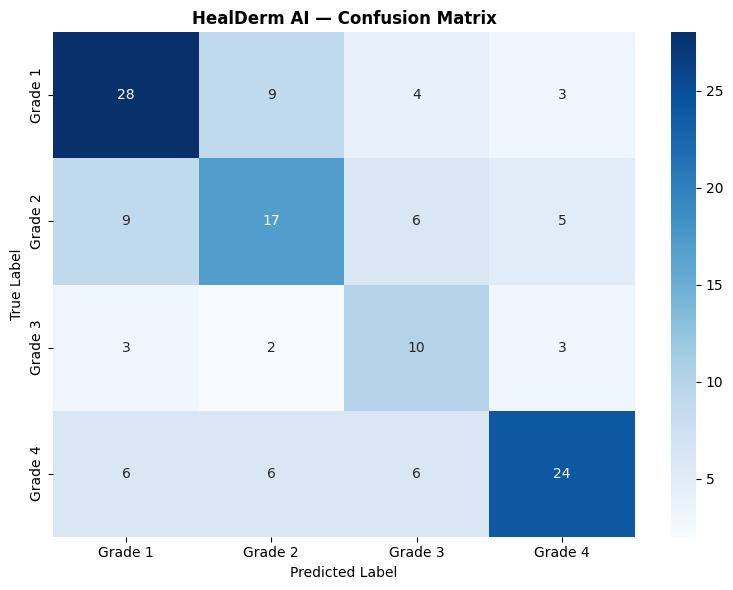


  Final Accuracy : 56.03%
  F1 Weighted    : 0.5635


In [23]:
# ── CELL 6 (Fixed) — Evaluate ──────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

final_model = keras.models.load_model(ckpt_p2)

test_gen.reset()
results = final_model.evaluate(test_gen, verbose=1)
for name, val in zip(
    ['Loss','Accuracy','AUC','Precision','Recall'], results
):
    print(f"  {name:<12}: {val:.4f}")

test_gen.reset()
y_prob = final_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_gen.classes

grade_labels = [f'Grade {i+1}' for i in range(4)]
print("\n" + classification_report(y_true, y_pred,
                                    target_names=grade_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=grade_labels,
            yticklabels=grade_labels)
plt.title('HealDerm AI — Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

acc  = accuracy_score(y_true, y_pred)
f1_w = f1_score(y_true, y_pred, average='weighted')
print(f"\n  Final Accuracy : {acc*100:.2f}%")
print(f"  F1 Weighted    : {f1_w:.4f}")


In [24]:
# Check if Phase 2 checkpoint exists
import os
ckpt_p2 = os.path.join(SAVE_DIR, 'best_phase2.keras')
if os.path.exists(ckpt_p2):
    print("✅ Phase 2 model exists — load it for evaluation")
else:
    print("❌ Phase 2 not trained yet — run Cell 5 first!")

✅ Phase 2 model exists — load it for evaluation


In [25]:
# ── CELL 1 — Re-split data only ───────────────────────────────────
import os, shutil, numpy as np
from sklearn.model_selection import train_test_split

BASE_DIR = '/content/HealDermAI'
NEW_DIR  = '/content/HealDermAI_fixed'
grades   = sorted(os.listdir(os.path.join(BASE_DIR, 'train')))

print("📦 Re-splitting data 80/10/10...")
for grade in grades:
    all_images = []
    for split in ['train', 'valid', 'test']:
        folder = os.path.join(BASE_DIR, split, grade)
        if os.path.exists(folder):
            for img in os.listdir(folder):
                if img.lower().endswith(('.jpg','.jpeg','.png')):
                    all_images.append(os.path.join(folder, img))

    train_imgs, temp      = train_test_split(all_images, test_size=0.20, random_state=42)
    valid_imgs, test_imgs = train_test_split(temp,       test_size=0.50, random_state=42)

    for split_name, imgs in [('train', train_imgs),
                              ('valid', valid_imgs),
                              ('test',  test_imgs)]:
        dest = os.path.join(NEW_DIR, split_name, grade)
        os.makedirs(dest, exist_ok=True)
        for img_path in imgs:
            shutil.copy(img_path, dest)

    print(f"  {grade}: train={len(train_imgs)}  valid={len(valid_imgs)}  test={len(test_imgs)}")

print("✅ Done!")

📦 Re-splitting data 80/10/10...
  Grade 1: train=1896  valid=237  test=237
  Grade 2: train=1968  valid=246  test=246
  Grade 3: train=2241  valid=280  test=281
  Grade 4: train=1944  valid=243  test=243
✅ Done!


In [26]:
# ── CELL 2 — New test generator on fixed split ─────────────────────
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

NEW_TEST_DIR = '/content/HealDermAI_fixed/test'

test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)
new_test_gen = test_datagen.flow_from_directory(
    NEW_TEST_DIR,
    target_size = (224, 224),
    batch_size  = 32,
    class_mode  = 'categorical',
    shuffle     = False
)
print(f"✅ New test set: {new_test_gen.samples} images")

Found 1007 images belonging to 4 classes.
✅ New test set: 1007 images


✅ Loaded best_phase2.keras

32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 541ms/step - accuracy: 0.7925 - auc: 0.9497 - loss: 0.5532 - precision: 0.8546 - recall: 0.7061
  Loss        : 0.5532
  Accuracy    : 0.7925
  AUC         : 0.9497
  Precision   : 0.8546
  Recall      : 0.7061

              precision    recall  f1-score   support

     Grade 1       0.62      0.91      0.74       237
     Grade 2       0.84      0.70      0.76       246
     Grade 3       0.87      0.74      0.80       281
     Grade 4       0.93      0.84      0.88       243

    accuracy                           0.79      1007
   macro avg       0.82      0.80      0.80      1007
weighted avg       0.82      0.79      0.80      1007



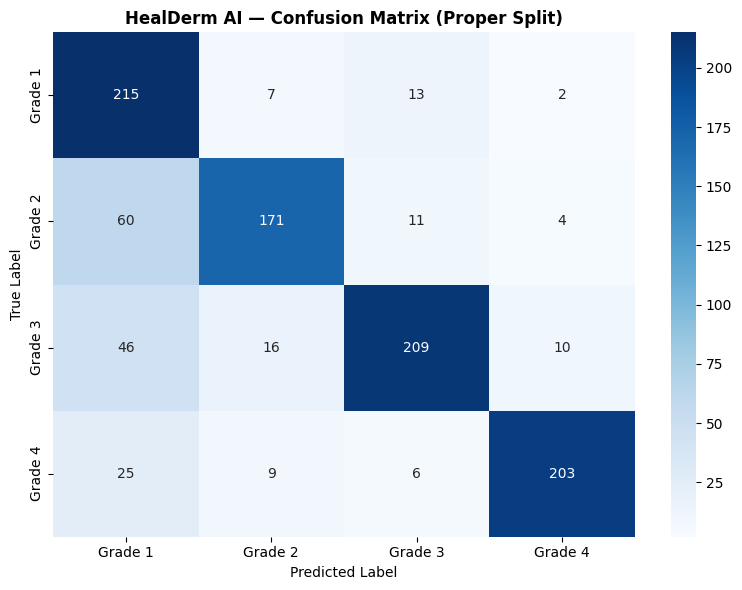


  ✅ Real Accuracy : 79.25%
  ✅ F1 Weighted   : 0.7960


In [27]:
# ── CELL 3 — Load saved model & evaluate on new test set ──────────
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load your already trained model
SAVE_DIR  = '/content/HealDermAI/saved_models'
ckpt_p2   = os.path.join(SAVE_DIR, 'best_phase2.keras')
final_model = keras.models.load_model(ckpt_p2)
print("✅ Loaded best_phase2.keras\n")

# Evaluate
new_test_gen.reset()
results = final_model.evaluate(new_test_gen, verbose=1)
for name, val in zip(['Loss','Accuracy','AUC','Precision','Recall'], results):
    print(f"  {name:<12}: {val:.4f}")

# Predictions
new_test_gen.reset()
y_prob = final_model.predict(new_test_gen, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = new_test_gen.classes

grade_labels = ['Grade 1','Grade 2','Grade 3','Grade 4']
print("\n" + classification_report(y_true, y_pred, target_names=grade_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=grade_labels, yticklabels=grade_labels)
plt.title('HealDerm AI — Confusion Matrix (Proper Split)', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

acc  = accuracy_score(y_true, y_pred)
f1_w = f1_score(y_true, y_pred, average='weighted')
print(f"\n  ✅ Real Accuracy : {acc*100:.2f}%")
print(f"  ✅ F1 Weighted   : {f1_w:.4f}")